In [47]:
!pip install pybaseball

---

### Data Collection

- **Season:** 2025 MLB Regular Season  
- **Date range:** 2025-03-28 to 2025-09-30  
- **Endpoint parameter:** `minSwings = 50` (note: does not perfectly correspond to returned `competitive_swings` values — see Section 3.2)  
- **Aggregation:** Season-level; one row per player


---
## Data Loading

The cell below loads bat-tracking data from Baseball Savant using a reusable function. Raw data is saved to `data/raw/` for reproducibility.


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests
import warnings
import unicodedata
import re
from io import StringIO
from urllib.parse import urlencode
from pathlib import Path
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "font.size": 10,
})

OUTPUT_DIR = Path("outputs")
DATA_RAW   = Path("data/raw")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_RAW.mkdir(parents=True, exist_ok=True)

print("Libraries loaded. Output directory:", OUTPUT_DIR.resolve())


Libraries loaded. Output directory: /content/outputs


In [49]:
def clean_colname(c: str) -> str:
    return re.sub(r"[^a-z0-9_]", "_", c.strip().lower()).strip("_")


def normalize_player_name(name: str) -> str:
    name = str(name).lower().strip()

    # Convert 'last, first' to 'first last' before removing punctuation
    if "," in name:
        parts = name.split(",", 1)
        name  = parts[1].strip() + " " + parts[0].strip()

    name = unicodedata.normalize("NFD", name)
    name = "".join(c for c in name if unicodedata.category(c) != "Mn")
    name = re.sub(r"[^a-z\s]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


def load_bat_tracking(
    date_start: str = "2025-03-28",
    date_end: str = "2025-09-30",
    season_start: int = 2025,
    season_end: int = 2025,
    player_type: str = "batter",
    min_swings: int = 50,
    game_type: str = "Regular",
) -> pd.DataFrame:
    """
    Load the Baseball Savant Statcast bat-tracking leaderboard as a DataFrame.
    """
    base_url = (
        "https://baseballsavant.mlb.com/"
        "leaderboard/bat-tracking/swing-path-attack-angle"
    )
    params = {
        "dateStart":      date_start,
        "dateEnd":        date_end,
        "gameType":       game_type,
        "minSwings":      min_swings,
        "minGroupSwings": 1,
        "seasonStart":    season_start,
        "seasonEnd":      season_end,
        "type":           player_type,
        "csv":            "true",
    }
    url      = base_url + "?" + urlencode(params)
    headers  = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status()

    text = response.text
    if "<html" in text.lower():
        raise ValueError(
            "Baseball Savant returned HTML instead of CSV. "
            "Check URL parameters or rate-limit status."
        )

    df = pd.read_csv(StringIO(text))
    df["date_start"] = date_start
    df["date_end"]   = date_end
    df.columns       = [clean_colname(c) for c in df.columns]
    return df


# Load full-season data
SEASON = 2025
DATE_START = "2025-03-28"
DATE_END = "2025-09-30"
QUERY_MIN_SWINGS = 50   # endpoint parameter only; not a guaranteed hard floor

bat_2025 = load_bat_tracking(
    date_start = DATE_START,
    date_end = DATE_END,
    season_start = SEASON,
    season_end = SEASON,
    min_swings = QUERY_MIN_SWINGS,
)

print(f"Returned by Baseball Savant leaderboard: {bat_2025.shape[0]} players × {bat_2025.shape[1]} columns")
print("Columns:", bat_2025.columns.tolist())

raw_path = DATA_RAW / "bat_tracking_2025_raw.csv"
bat_2025.to_csv(raw_path, index=False)
print(f"\nRaw data saved to: {raw_path}")


Returned by Baseball Savant leaderboard: 587 players × 15 columns
Columns: ['id', 'name', 'side', 'avg_bat_speed', 'swing_tilt', 'attack_angle', 'attack_direction', 'ideal_attack_angle_rate', 'avg_intercept_y_vs_plate', 'avg_intercept_y_vs_batter', 'avg_batter_y_position', 'avg_batter_x_position', 'competitive_swings', 'date_start', 'date_end']

Raw data saved to: data/raw/bat_tracking_2025_raw.csv


---
## Data Quality and Missingness

In [50]:
print(f"Rows (players in leaderboard extract) : {bat_2025.shape[0]}")
print(f"Columns                               : {bat_2025.shape[1]}")
print(f"Date range (metadata)                 : {bat_2025['date_start'].iloc[0]} → {bat_2025['date_end'].iloc[0]}")
print(f"Unique player IDs                     : {bat_2025['id'].nunique()}")
print(f"Duplicate IDs                         : {bat_2025['id'].duplicated().sum()}")
print(f"competitive_swings min (actual)       : {bat_2025['competitive_swings'].min()}")
print(f"competitive_swings max (actual)       : {bat_2025['competitive_swings'].max()}")



Rows (players in leaderboard extract) : 587
Columns                               : 15
Date range (metadata)                 : 2025-03-28 → 2025-09-30
Unique player IDs                     : 587
Duplicate IDs                         : 0
competitive_swings min (actual)       : 28
competitive_swings max (actual)       : 1273


### Missing-Value Table


In [51]:
missing_summary = pd.DataFrame({
    "column": bat_2025.columns,
    "dtype": [str(bat_2025[c].dtype) for c in bat_2025.columns],
    "non_null": [bat_2025[c].notna().sum()  for c in bat_2025.columns],
    "missing_count": [bat_2025[c].isna().sum()   for c in bat_2025.columns],
    "missing_pct": [round(bat_2025[c].isna().mean()*100, 2) for c in bat_2025.columns],
}).reset_index(drop=True)

missing_summary.sort_values("missing_pct", ascending=False)


,column,dtype,non_null,missing_count,missing_pct
0,id,int64,587,0,0.0
1,name,object,587,0,0.0
2,side,object,587,0,0.0
3,avg_bat_speed,float64,587,0,0.0
4,swing_tilt,float64,587,0,0.0
5,attack_angle,float64,587,0,0.0
6,attack_direction,float64,587,0,0.0
7,ideal_attack_angle_rate,float64,587,0,0.0
8,avg_intercept_y_vs_plate,float64,587,0,0.0
9,avg_intercept_y_vs_batter,float64,587,0,0.0


### Filter Sensitivity — `competitive_swings` Thresholds


In [52]:
thresholds = [50, 100, 150, 200, 300]
filter_df = pd.DataFrame({
    "min_competitive_swings": thresholds,
    "n_players": [
        (bat_2025["competitive_swings"] >= t).sum() for t in thresholds
    ],
    "pct_retained": [
        round((bat_2025["competitive_swings"] >= t).mean() * 100, 1)
        for t in thresholds
    ],
})
print(filter_df.to_string(index=False))
print()
print("The main ranking table uses competitive_swings >= 100.")
print("The reliability-adjustment formula provides a continuous alternative for all players.")


 min_competitive_swings  n_players  pct_retained
                     50        579          98.6
                    100        512          87.2
                    150        462          78.7
                    200        422          71.9
                    300        361          61.5

The main ranking table uses competitive_swings >= 100.
The reliability-adjustment formula provides a continuous alternative for all players.


---
## Descriptive Statistics

Descriptive statistics for core bat-tracking and derived variables across all 587 players in the dataset.


In [53]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standardize avg_bat_speed
scaler = StandardScaler()
bat_2025["raw_swing_power_score"] = scaler.fit_transform(
    bat_2025[["avg_bat_speed"]]
)

# Standardize ideal_attack_angle_rate
bat_2025["swing_path_efficiency_score"] = scaler.fit_transform(
    bat_2025[["ideal_attack_angle_rate"]]
)

# Calculate mechanical_swing_quality_score
bat_2025["mechanical_swing_quality_score"] = (
    0.50 * bat_2025["raw_swing_power_score"]
    + 0.50 * bat_2025["swing_path_efficiency_score"]
)

# Calculate msq_reliability
bat_2025["msq_reliability"] = 1 - np.exp(
    -bat_2025["competitive_swings"] / 100
)

# Calculate mechanical_swing_quality_shrunk
bat_2025["mechanical_swing_quality_shrunk"] = (
    bat_2025["mechanical_swing_quality_score"]
    * bat_2025["msq_reliability"]
)

summary_vars = [
    "avg_bat_speed",
    "ideal_attack_angle_rate",
    "attack_angle",
    "swing_tilt",
    "competitive_swings",
    "mechanical_swing_quality_score",
    "mechanical_swing_quality_shrunk",
    "msq_reliability",
]

summary = (
    bat_2025[summary_vars]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .rename(columns={
        "count": "N", "mean": "Mean", "std": "SD",
        "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max",
    })
    .round(3)
)
summary

,N,Mean,SD,Min,Q1,Median,Q3,Max
avg_bat_speed,587.0,71.509,2.642,62.641,69.704,71.654,73.338,80.620
ideal_attack_angle_rate,587.0,0.508,0.085,0.155,0.459,0.507,0.562,0.747
attack_angle,587.0,10.036,3.639,-4.039,7.620,9.957,12.325,21.398
swing_tilt,587.0,32.069,3.834,19.613,29.383,31.950,34.621,44.623
competitive_swings,587.0,497.533,341.835,28.000,180.000,448.000,799.000,1273.000
mechanical_swing_quality_score,587.0,-0.000,0.734,-2.733,-0.414,0.042,0.484,2.383
mechanical_swing_quality_shrunk,587.0,0.009,0.655,-2.372,-0.368,0.035,0.401,2.356
msq_reliability,587.0,0.887,0.173,0.244,0.835,0.989,1.000,1.000


---
## Additional Bat-Tracking Variables

Checking descriptive statistics of rest of variables from bat-tracking data collected from Baseball Savant.

In [54]:
# Summary statistics for auxiliary bat-tracking variables
aux_vars = [
    "swing_tilt",
    "attack_angle",
    "attack_direction",
    "avg_intercept_y_vs_plate",
    "avg_intercept_y_vs_batter",
    "avg_batter_y_position",
    "avg_batter_x_position",
]

aux_summary = (
    bat_2025[aux_vars]
    .describe(percentiles=[0.25, 0.50, 0.75])
    .T
    .rename(columns={
        "count": "N", "mean": "Mean", "std": "SD",
        "min": "Min", "25%": "Q1", "50%": "Median", "75%": "Q3", "max": "Max",
    })
    .round(3)
)
aux_summary


,N,Mean,SD,Min,Q1,Median,Q3,Max
swing_tilt,587.0,32.069,3.834,19.613,29.383,31.950,34.621,44.623
attack_angle,587.0,10.036,3.639,-4.039,7.620,9.957,12.325,21.398
attack_direction,587.0,-1.924,4.554,-17.414,-5.011,-1.886,1.113,12.650
avg_intercept_y_vs_plate,587.0,2.846,4.778,-9.719,-0.377,2.477,6.119,23.234
avg_intercept_y_vs_batter,587.0,30.704,3.456,20.557,28.323,30.597,33.182,40.425
avg_batter_y_position,587.0,27.858,3.712,9.430,26.200,28.334,30.289,36.791
avg_batter_x_position,587.0,27.719,2.308,21.045,26.267,27.757,29.161,35.613


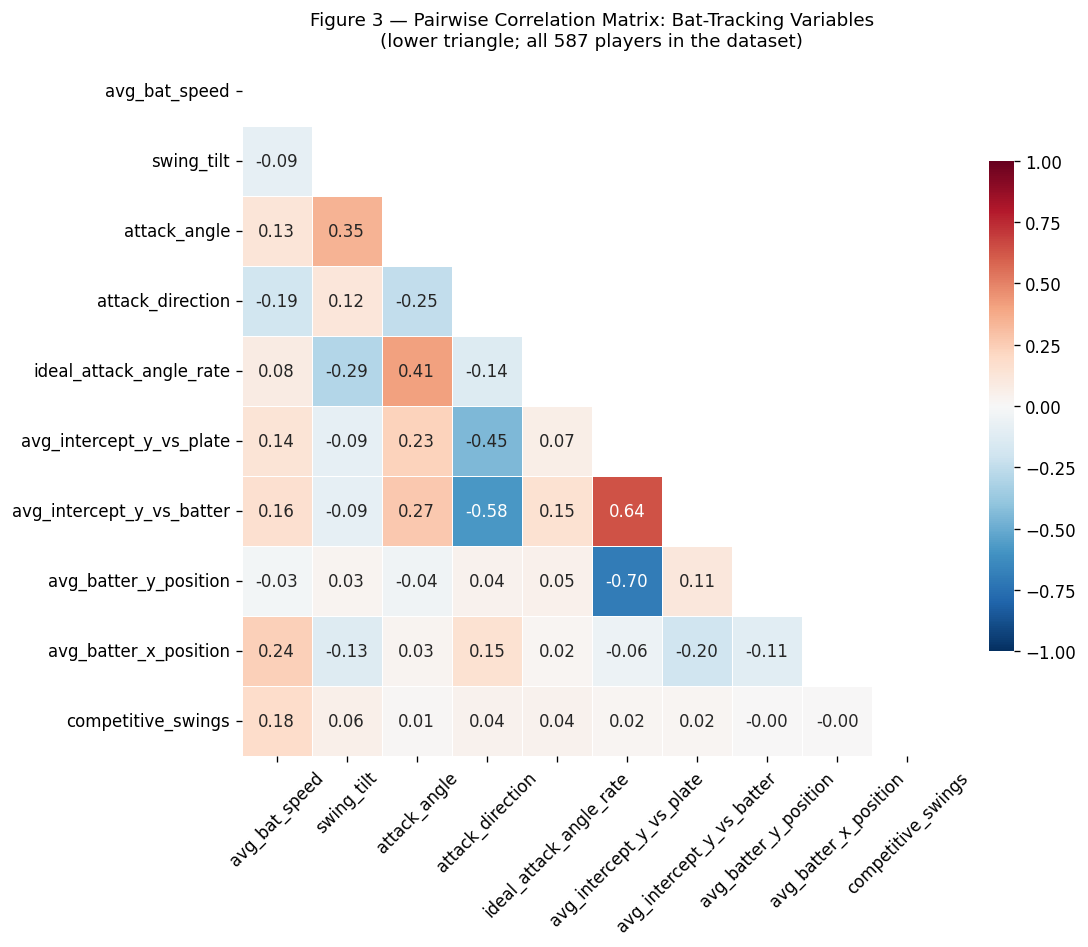

Figure 3 saved.


In [55]:
# Correlation heatmap: all numeric bat-tracking variables
numeric_bt_cols = [
    "avg_bat_speed", "swing_tilt", "attack_angle", "attack_direction",
    "ideal_attack_angle_rate",
    "avg_intercept_y_vs_plate", "avg_intercept_y_vs_batter",
    "avg_batter_y_position", "avg_batter_x_position",
    "competitive_swings",
]

corr_matrix = bat_2025[numeric_bt_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    ax=ax,
)
ax.set_title(
    "Figure 3 — Pairwise Correlation Matrix: Bat-Tracking Variables\n"
    "(lower triangle; all 587 players in the dataset)",
    fontsize=11,
)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("Figure 3 saved.")


---
## Distribution of Core Bat-Tracking Metrics

### Primary Mechanical Score Inputs


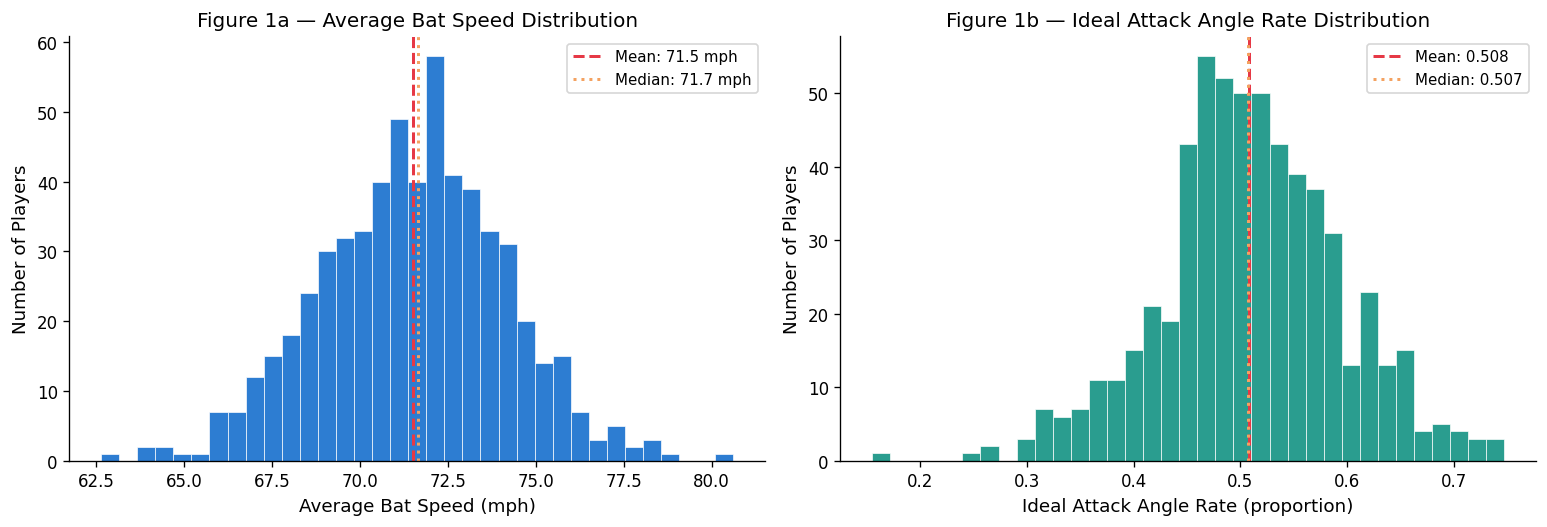

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(bat_2025["avg_bat_speed"], bins=35, color="#2d7dd2",
        edgecolor="white", linewidth=0.4)
ax.axvline(bat_2025["avg_bat_speed"].mean(),   color="#e63946", lw=1.8, ls="--",
           label=f'Mean: {bat_2025["avg_bat_speed"].mean():.1f} mph')
ax.axvline(bat_2025["avg_bat_speed"].median(), color="#f4a261", lw=1.8, ls=":",
           label=f'Median: {bat_2025["avg_bat_speed"].median():.1f} mph')
ax.set_title("Figure 1a — Average Bat Speed Distribution")
ax.set_xlabel("Average Bat Speed (mph)")
ax.set_ylabel("Number of Players")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(bat_2025["ideal_attack_angle_rate"], bins=35, color="#2a9d8f",edgecolor="white", linewidth=0.4)
ax.axvline(bat_2025["ideal_attack_angle_rate"].mean(),   color="#e63946", lw=1.8, ls="--", label=f'Mean: {bat_2025["ideal_attack_angle_rate"].mean():.3f}')
ax.axvline(bat_2025["ideal_attack_angle_rate"].median(), color="#f4a261", lw=1.8, ls=":", label=f'Median: {bat_2025["ideal_attack_angle_rate"].median():.3f}')
ax.set_title("Figure 1b — Ideal Attack Angle Rate Distribution")
ax.set_xlabel("Ideal Attack Angle Rate (proportion)")
ax.set_ylabel("Number of Players")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_primary_inputs.png", bbox_inches="tight")
plt.show()


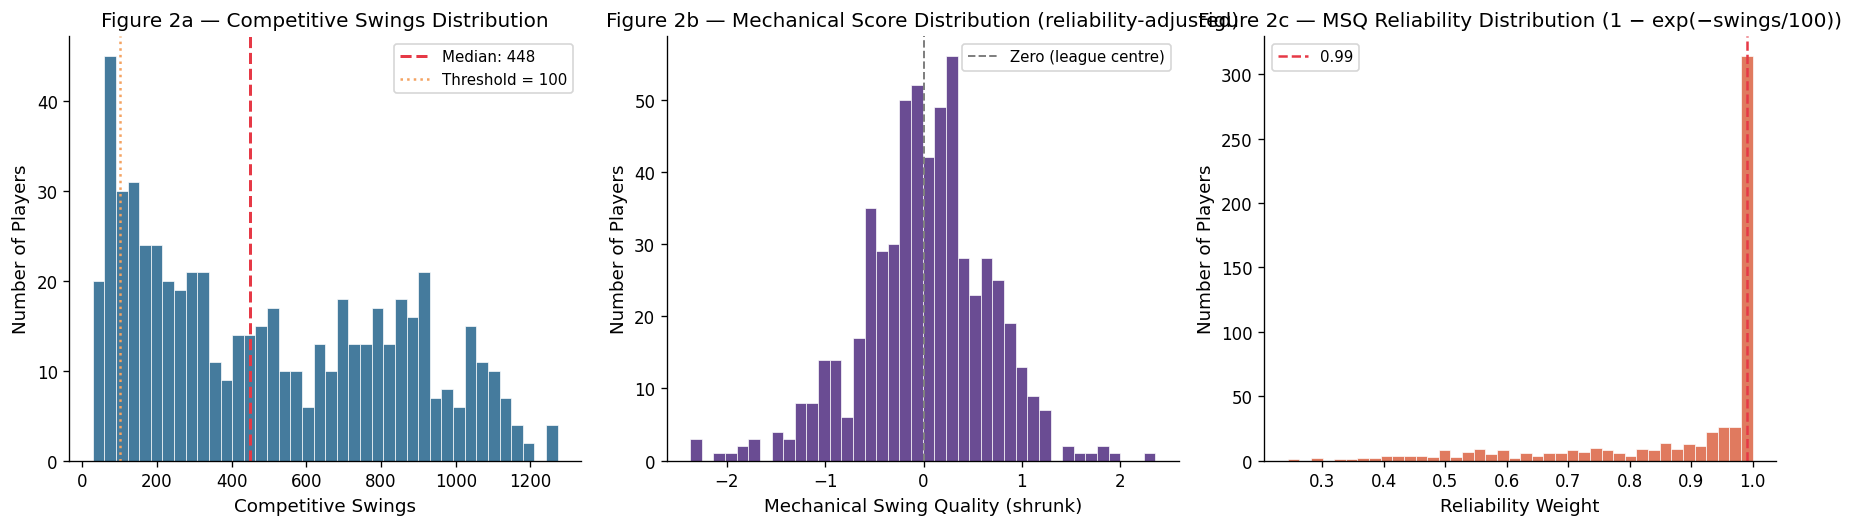

Figure 2 saved.


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.hist(bat_2025["competitive_swings"], bins=40, color="#457b9d", edgecolor="white", linewidth=0.4)
ax.axvline(bat_2025["competitive_swings"].median(), color="#e63946", lw=1.8, ls="--", label=f'Median: {bat_2025["competitive_swings"].median():.0f}')
ax.axvline(100, color="#f4a261", lw=1.5, ls=":", label="Threshold = 100")
ax.set_title("Figure 2a — Competitive Swings Distribution")
ax.set_xlabel("Competitive Swings")
ax.set_ylabel("Number of Players")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(bat_2025["mechanical_swing_quality_shrunk"], bins=40, color="#6a4c93", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="gray", lw=1.2, ls="--", label="Zero (league centre)")
ax.set_title("Figure 2b — Mechanical Score Distribution (reliability-adjusted)")
ax.set_xlabel("Mechanical Swing Quality (shrunk)")
ax.set_ylabel("Number of Players")
ax.legend(fontsize=9)

ax = axes[2]
ax.hist(bat_2025["msq_reliability"], bins=40, color="#e07a5f", edgecolor="white", linewidth=0.4)
ax.axvline(0.99, color="#e63946", lw=1.5, ls="--", label="0.99")
ax.set_title("Figure 2c — MSQ Reliability Distribution (1 − exp(−swings/100))")
ax.set_xlabel("Reliability Weight")
ax.set_ylabel("Number of Players")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_swings_score_reliability.png", bbox_inches="tight")
plt.show()
print("Figure 2 saved.")


---
## Mechanical Swing Quality Score Construction

Two bat-tracking variables are selected as inputs to the exploratory mechanical profile score:

1. **`avg_bat_speed`**
2. **`ideal_attack_angle_rate`**

### Formula

$$
\text{Mechanical SQ Score}_i = 0.50 \times z(\texttt{avg_bat_speed}_i) + 0.50 \times z(\texttt{ideal_attack_angle_rate}_i)
$$

where $z(\cdot)$ denotes standardisation to mean 0, SD 1 across all 587 players in the dataset. The equal weighting is provisional; weights should be validated empirically against outcome metrics after the data join.


In [58]:
# Score construction already applied in Section 6D; verify here
print("Construction verification:")
print(f" z(avg_bat_speed) mean: {bat_2025['raw_swing_power_score'].mean():.5f}  "
      f"SD: {bat_2025['raw_swing_power_score'].std():.5f}")
print(f" z(ideal_attack_angle_rate) mean: {bat_2025['swing_path_efficiency_score'].mean():.5f}  "
      f"SD: {bat_2025['swing_path_efficiency_score'].std():.5f}")
print(f" mechanical_swing_quality_score "
      f"mean: {bat_2025['mechanical_swing_quality_score'].mean():.5f}  "
      f"SD: {bat_2025['mechanical_swing_quality_score'].std():.5f}")

r = bat_2025[["raw_swing_power_score","swing_path_efficiency_score"]].corr().iloc[0,1]
print(f"\nPearson r(z_bat_speed, z_ideal_angle_rate) = {r:.3f}")


Construction verification:
 z(avg_bat_speed) mean: -0.00000  SD: 1.00085
 z(ideal_attack_angle_rate) mean: 0.00000  SD: 1.00085
 mechanical_swing_quality_score mean: -0.00000  SD: 0.73393

Pearson r(z_bat_speed, z_ideal_angle_rate) = 0.075


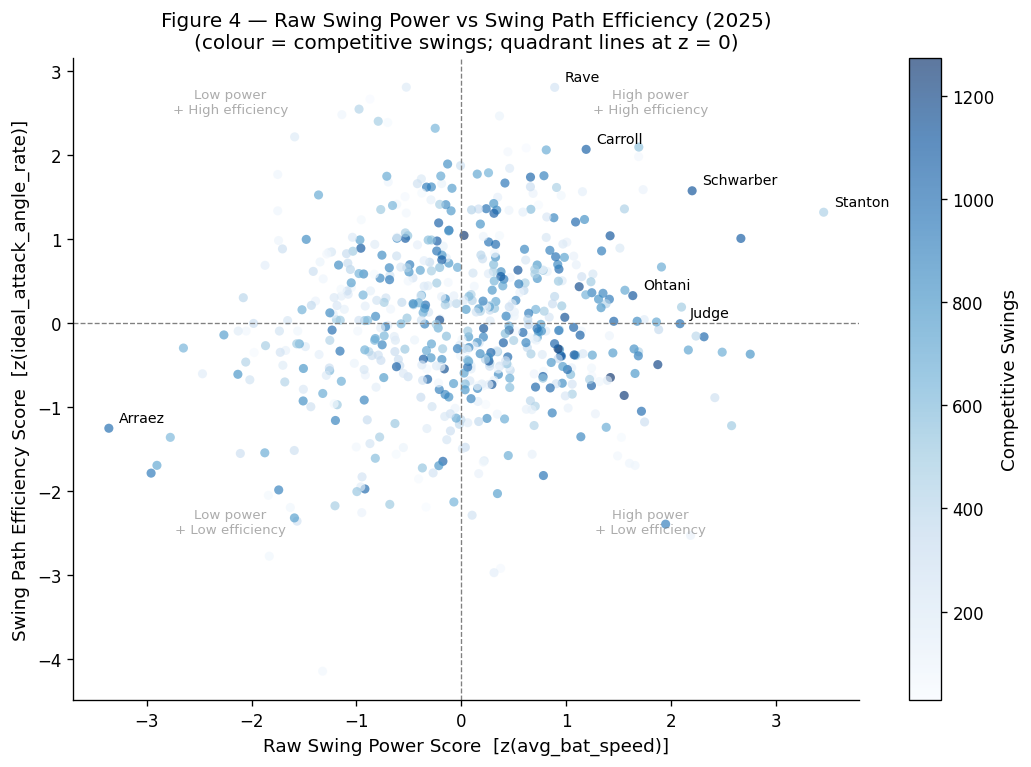

Figure 4 saved.


In [59]:
# Scatter: power score vs efficiency score
fig, ax = plt.subplots(figsize=(9, 6.5))

scatter = ax.scatter(
    bat_2025["raw_swing_power_score"],
    bat_2025["swing_path_efficiency_score"],
    c=bat_2025["competitive_swings"],
    cmap="Blues", alpha=0.65, s=30, edgecolors="none",
)
plt.colorbar(scatter, ax=ax, label="Competitive Swings")
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axvline(0, color="gray", lw=0.8, ls="--")

for full_name, label in [
    ("stanton, giancarlo", "Stanton"),
    ("schwarber, kyle", "Schwarber"),
    ("carroll, corbin", "Carroll"),
    ("judge, aaron", "Judge"),
    ("rave, john", "Rave"),
    ("arraez, luis", "Arraez"),
    ("ohtani, shohei", "Ohtani"),
]:
    row = bat_2025[bat_2025["name"].str.lower() == full_name]
    if not row.empty:
        ax.annotate(label,
                    xy=(row["raw_swing_power_score"].values[0],
                        row["swing_path_efficiency_score"].values[0]),
                    xytext=(6, 4), textcoords="offset points", fontsize=8.5)

kw = dict(fontsize=8, color="gray", ha="center", alpha=0.65)
ax.text( 1.8,  2.5, "High power\n+ High efficiency", **kw)
ax.text(-2.2,  2.5, "Low power\n+ High efficiency", **kw)
ax.text( 1.8, -2.5, "High power\n+ Low efficiency", **kw)
ax.text(-2.2, -2.5, "Low power\n+ Low efficiency",  **kw)

ax.set_xlabel("Raw Swing Power Score  [z(avg_bat_speed)]")
ax.set_ylabel("Swing Path Efficiency Score  [z(ideal_attack_angle_rate)]")
ax.set_title("Figure 4 — Raw Swing Power vs Swing Path Efficiency (2025)\n"
             "(colour = competitive swings; quadrant lines at z = 0)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_power_vs_efficiency.png", bbox_inches="tight")
plt.show()
print("Figure 4 saved.")


---
## Reliability Adjustment Using Competitive Swings

Season-aggregate bat-tracking statistics are computed over varying numbers of competitive swings. A player with 900 swings has a much more stable estimate than one with 60. Without adjustment, both would be treated equally in a ranking, which would over-represent the uncertainty inherent in small-sample estimates.

The reliability-adjusted (shrunk) score applies a continuous down-weighting based on observation volume, shrinking low-volume estimates toward the league mean (zero) while leaving high-volume players' scores largely intact.

### Formulas

$$\text{Reliability}_i = 1 - e^{-\text{competitive\_swings}_i / 100}$$

$$\text{Mechanical SQ Shrunk}_i = \text{Mechanical SQ Score}_i \times \text{Reliability}_i$$

$$\text{Uncertainty Proxy}_i = \frac{1}{\sqrt{\text{competitive\_swings}_i}}$$


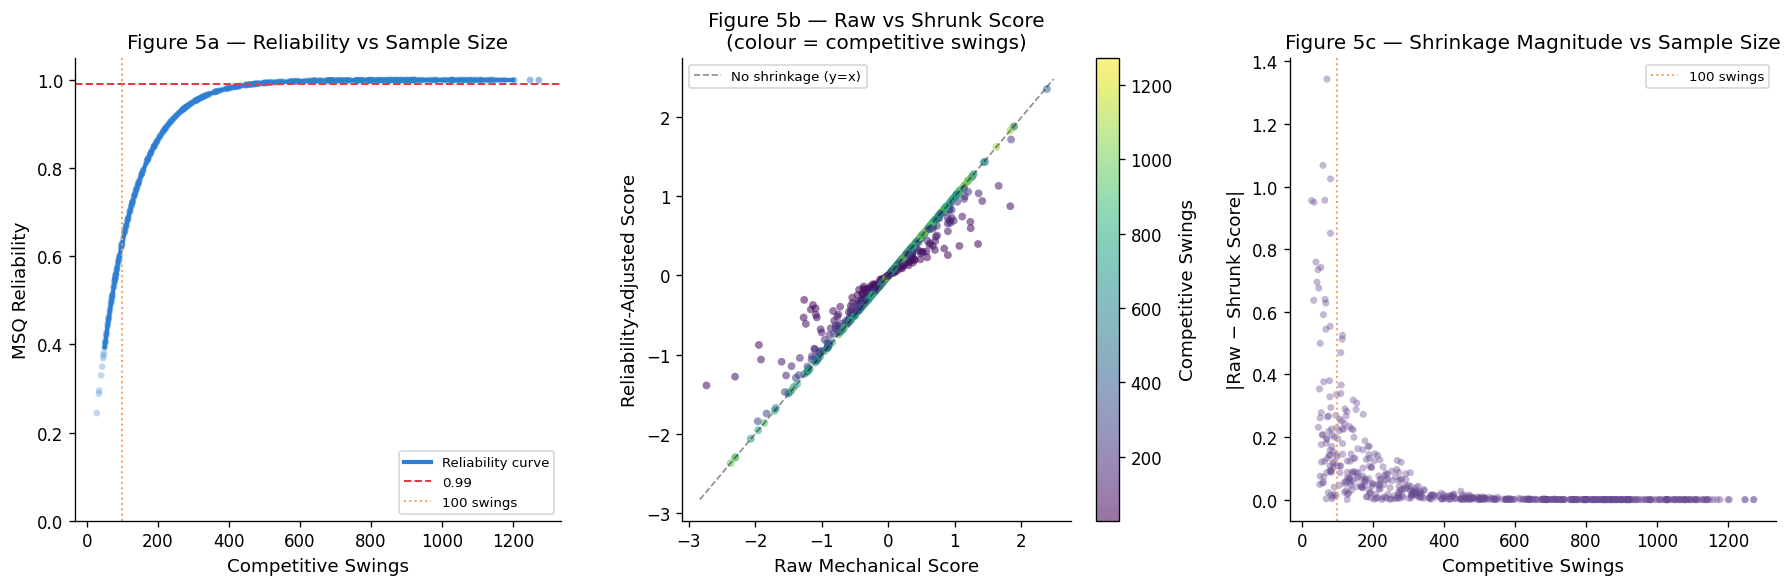

Figure 5 saved.


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: reliability curve
ax = axes[0]
x = np.linspace(50, 1200, 500)
y = 1 - np.exp(-x / 100)
ax.plot(x, y, color="#2d7dd2", lw=2.5, label="Reliability curve")
ax.scatter(bat_2025["competitive_swings"], bat_2025["msq_reliability"],
           alpha=0.3, s=16, color="#2d7dd2", edgecolors="none")
ax.axhline(0.99, color="#e63946", lw=1.2, ls="--", label="0.99")
ax.axvline(100,  color="#f4a261", lw=1.2, ls=":",  label="100 swings")
ax.set_xlabel("Competitive Swings")
ax.set_ylabel("MSQ Reliability")
ax.set_title("Figure 5a — Reliability vs Sample Size")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# Panel 2: raw vs shrunk
ax = axes[1]
sc = ax.scatter(bat_2025["mechanical_swing_quality_score"],
                bat_2025["mechanical_swing_quality_shrunk"],
                c=bat_2025["competitive_swings"], cmap="viridis",
                alpha=0.55, s=22, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Competitive Swings")
lims = [bat_2025["mechanical_swing_quality_score"].min()-0.1,
        bat_2025["mechanical_swing_quality_score"].max()+0.1]
ax.plot(lims, lims, "k--", lw=1, alpha=0.45, label="No shrinkage (y=x)")
ax.set_xlabel("Raw Mechanical Score")
ax.set_ylabel("Reliability-Adjusted Score")
ax.set_title("Figure 5b — Raw vs Shrunk Score\n(colour = competitive swings)")
ax.legend(fontsize=8)

# Panel 3: shrinkage effect
ax = axes[2]
bat_2025["score_delta"] = (bat_2025["mechanical_swing_quality_score"]
                            - bat_2025["mechanical_swing_quality_shrunk"]).abs()
ax.scatter(bat_2025["competitive_swings"], bat_2025["score_delta"],
           alpha=0.4, s=18, color="#6a4c93", edgecolors="none")
ax.axvline(100, color="#f4a261", lw=1.2, ls=":", label="100 swings")
ax.set_xlabel("Competitive Swings")
ax.set_ylabel("|Raw − Shrunk Score|")
ax.set_title("Figure 5c — Shrinkage Magnitude vs Sample Size")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig5_reliability_panels.png", bbox_inches="tight")
plt.show()
print("Figure 5 saved.")


---
## Player Ranking and Profile Analysis

The ranking table below uses `competitive_swings ≥ 100` as the analysis threshold. All players in the public bat-tracking dataset are retained in the full data; this filter is applied for the main ranking display only.

> **Wording note:** Rankings reflect performance under this two-variable bat-tracking mechanical profile index. They do not reflect overall batting value, true talent, or expected offensive production.


In [61]:
def label_percentile(p: float) -> str:
    if p >= 90: return "Elite"
    elif p >= 75: return "Strong"
    elif p >= 50: return "Above-average"
    elif p >= 25: return "Below-average"
    else: return "Low"


bat_2025["mechanical_swing_quality_percentile"] = (
    bat_2025["mechanical_swing_quality_score"].rank(pct=True) * 100
)
bat_2025["mechanical_swing_quality_shrunk_percentile"] = (
    bat_2025["mechanical_swing_quality_shrunk"].rank(pct=True) * 100
)
bat_2025["mechanical_swing_quality_adjusted_label"] = (
    bat_2025["mechanical_swing_quality_shrunk_percentile"].apply(label_percentile)
)
bat_2025["name_norm"] = bat_2025["name"].apply(normalize_player_name)

RANK_MIN_SWINGS = 100

ranking_df = (
    bat_2025[bat_2025["competitive_swings"] >= RANK_MIN_SWINGS][
        ["name", "side", "avg_bat_speed", "ideal_attack_angle_rate",
         "competitive_swings", "mechanical_swing_quality_score",
         "mechanical_swing_quality_shrunk",
         "mechanical_swing_quality_shrunk_percentile",
         "msq_reliability",
         "mechanical_swing_quality_adjusted_label"]
    ]
    .sort_values("mechanical_swing_quality_shrunk", ascending=False)
    .reset_index(drop=True)
)
ranking_df.index += 1
ranking_df.index.name = "Rank"

print(f"Players with competitive_swings ≥ {RANK_MIN_SWINGS}: {len(ranking_df)}")
ranking_df.head(25).round(3)


Players with competitive_swings ≥ 100: 512


,name,side,avg_bat_speed,ideal_attack_angle_rate,competitive_swings,mechanical_swing_quality_score,mechanical_swing_quality_shrunk,mechanical_swing_quality_shrunk_percentile,msq_reliability,mechanical_swing_quality_adjusted_label
Rank,,,,,,,,,,
1,"Stanton, Giancarlo",R,80.620,0.621,448,2.383,2.356,100.000,0.989,Elite
2,"Schwarber, Kyle",L,77.312,0.642,1135,1.884,1.884,99.830,1.000,Elite
3,"Morel, Christopher",R,75.971,0.687,552,1.890,1.882,99.659,0.996,Elite
4,"Caminero, Junior",R,78.538,0.594,1091,1.833,1.833,99.489,1.000,Elite
5,"Rave, John",L,73.855,0.747,269,1.844,1.719,99.319,0.932,Elite
6,"Carroll, Corbin",L,74.646,0.684,1077,1.625,1.625,99.148,1.000,Elite
7,"Varsho, Daulton",L,75.609,0.624,452,1.454,1.438,98.978,0.989,Elite
8,"Lewis, Royce",R,73.642,0.684,683,1.432,1.431,98.807,0.999,Elite
9,"Wallner, Matt",L,76.541,0.565,685,1.285,1.283,98.637,0.999,Elite


In [62]:
# Rank-change analysis: raw score vs shrunk score
df_cmp = bat_2025[bat_2025["competitive_swings"] >= RANK_MIN_SWINGS].copy()
df_cmp["rank_raw"] = df_cmp["mechanical_swing_quality_score"].rank(ascending=False).astype(int)
df_cmp["rank_shrunk"] = df_cmp["mechanical_swing_quality_shrunk"].rank(ascending=False).astype(int)
df_cmp["rank_change"] = df_cmp["rank_raw"] - df_cmp["rank_shrunk"]

movers = (
    df_cmp[["name","competitive_swings","msq_reliability","rank_raw","rank_shrunk","rank_change"]]
    .sort_values("rank_change", key=abs, ascending=False)
    .head(15)
    .reset_index(drop=True)
)
movers.index += 1
print("Largest rank differences (raw → shrunk):")
movers.round(3)


Largest rank differences (raw → shrunk):


,name,competitive_swings,msq_reliability,rank_raw,rank_shrunk,rank_change
1,"Pereira, Everson",122,0.705,37,83,-46
2,"Kelenic, Jarred",111,0.670,25,71,-46
3,"Robertson, Will",125,0.713,44,88,-44
4,"Johnson, Bryce",107,0.657,444,403,41
5,"Seymour, Bob",134,0.738,51,92,-41
6,"Crim, Blaine",116,0.687,85,124,-39
7,"Hilliard, Sam",105,0.650,103,141,-38
8,"Winker, Jesse",117,0.690,82,118,-36
9,"Heyward, Jason",140,0.753,47,82,-35
10,"Maton, Nick",102,0.639,408,374,34


**Interpretation:** Rank changes between the raw and reliability-adjusted scores are concentrated among players with lower `competitive_swings`. Using the shrunk score as the primary ranking metric is the more conservative choice and reduces overinterpretation of small-sample estimates.
